# Setup

## Load packages

In [1]:
# Load up necessary packages. 
import os
import glob
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Import my custom utils.
import utils
importlib.reload(utils)

<module 'utils' from '/tscc/projects/ps-yeolab3/kflanagan/plip_plop/machine_learning_prototype/utils.py'>

## Load results

In [2]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/plip_plop_results/p2_processed_inputs/"

COMPARISON_TABLE = (
    "/tscc/nfs/home/kflanagan/projects/plip_plop/"
    "machine_learning_prototype/encode_initial_30_comparisons.tsv"
)

comparison_table = pd.read_csv(COMPARISON_TABLE, sep="\t")

# Organize data

In [3]:
all_signals = []
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]

    npz_file = os.path.join(INPUT_DIR, f"{experiment_A}_{experiment_B}.npz")

    if not os.path.exists(npz_file):
        print(f"Missing: {npz_file}")
        continue

    data = np.load(npz_file)

    # Load the final abundance-corrected, smoothed signal.
    signals = data["signals"].astype(np.float32)
    n_windows = len(signals)

    all_signals.append(signals)

    metadata = pd.DataFrame({
        "comparison_id": comparison_id,
        "category": row["category"],
        "experiment_A": experiment_A,
        "experiment_B": experiment_B,
        "chrom": data["chrom"],
        "start": data["start"],
        "end": data["end"],
        "strand": data["strand"],
        "region_id": data["region_id"],
        "block_number": data["block_number"],
        "signal_A": data["total_signal_A"],
        "signal_B": data["total_signal_B"],
        "total_signal": data["total_signal"]
    })

    all_metadata.append(metadata)

In [4]:
signals = np.concatenate(all_signals, axis=0)
metadata = pd.concat(all_metadata, ignore_index=True)

In [5]:
# Convert to pure magnitude (interested in positive and negative signal, for better or worse). 
magnitude = np.max(np.abs(signals), axis=1)
###!!!### I am really thinking about 0-ing out the negative signal. Like, negative signal means nothing? 

# Apply additional smoothing (not reall)
detection_signal = gaussian_filter1d(magnitude, sigma=2, axis=1)

# Decide the fraction of the max signal something needs to be for it to be considered part of 
signal_fraction = 0.30

# Perform the masking (get the meaningful signal regions). 
window_max = detection_signal.max(axis=1, keepdims=True)
signal_mask = (window_max > 0) & (detection_signal >= signal_fraction * window_max)

# Initial plotting

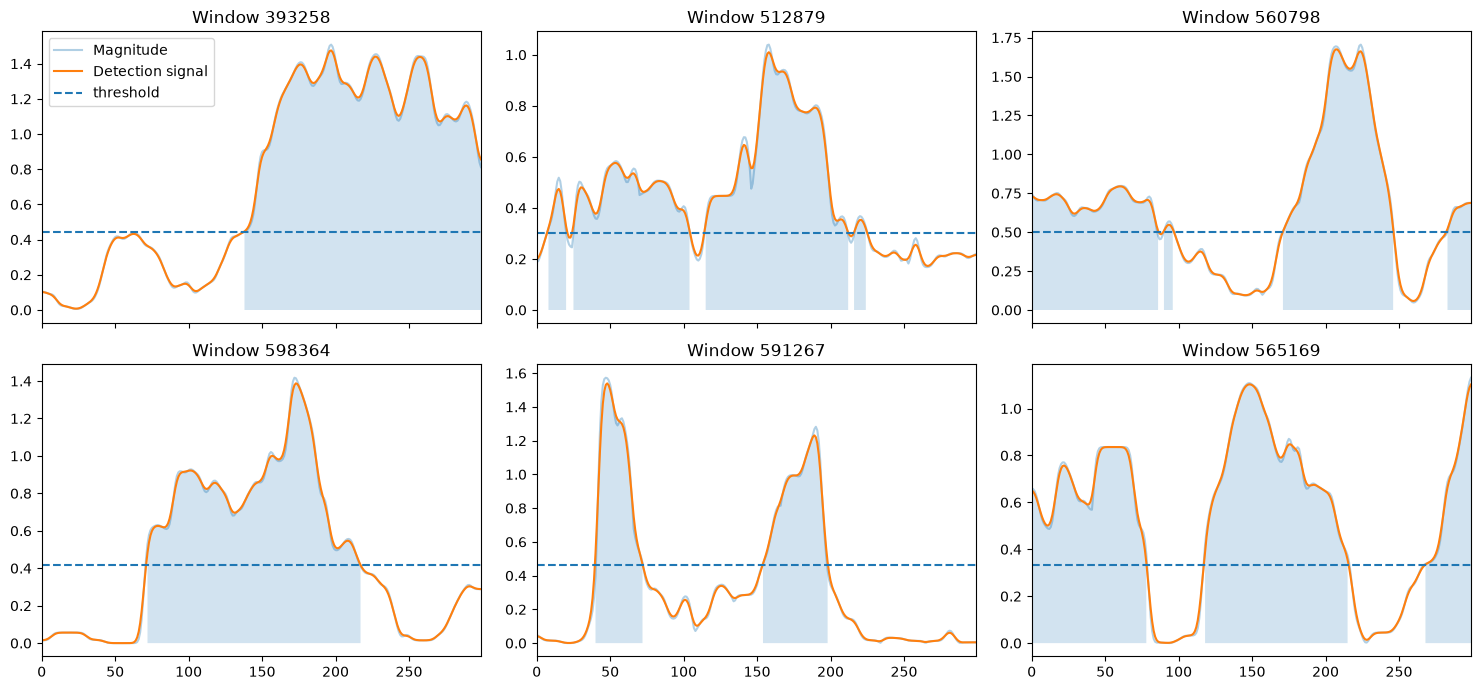

In [6]:
import matplotlib.pyplot as plt

idxs = np.random.default_rng(50).choice(len(detection_signal), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)

for idx, ax in zip(idxs, axes.flat):
    threshold = signal_fraction * detection_signal[idx].max()

    ax.plot(magnitude[idx], alpha=0.35, label="Magnitude")
    ax.plot(detection_signal[idx], label="Detection signal")
    ax.axhline(threshold, linestyle="--", label="threshold")
    ax.fill_between(np.arange(300), 0, detection_signal[idx], where=signal_mask[idx], alpha=0.2)

    ax.set_title(f"Window {idx}")
    ax.set_xlim(0, 299)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

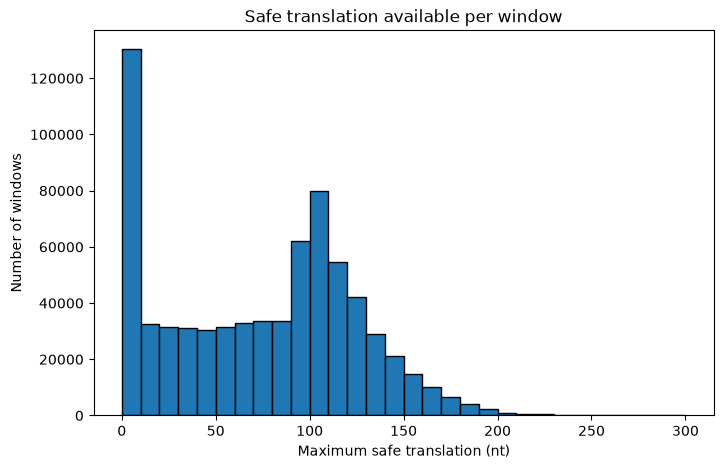

≥  10 nt: 81.8%
≥  25 nt: 75.1%
≥  50 nt: 64.3%
≥  75 nt: 53.0%
≥ 100 nt: 37.4%


In [7]:
left_margin = np.zeros(len(signal_mask), dtype=int)
right_margin = np.zeros(len(signal_mask), dtype=int)

for i, mask in enumerate(signal_mask):
    pos = np.flatnonzero(mask)
    if len(pos):
        left_margin[i] = pos[0]
        right_margin[i] = 299 - pos[-1]

max_shift = np.maximum(left_margin, right_margin)

plt.figure(figsize=(8, 5))
plt.hist(max_shift, bins=np.arange(0, 305, 10), edgecolor="black")
plt.xlabel("Maximum safe translation (nt)")
plt.ylabel("Number of windows")
plt.title("Safe translation available per window")
plt.show()

for cutoff in [10, 25, 50, 75, 100]:
    print(f"≥ {cutoff:3d} nt: {np.mean(max_shift >= cutoff):.1%}")

# Squishing gaps and bridges

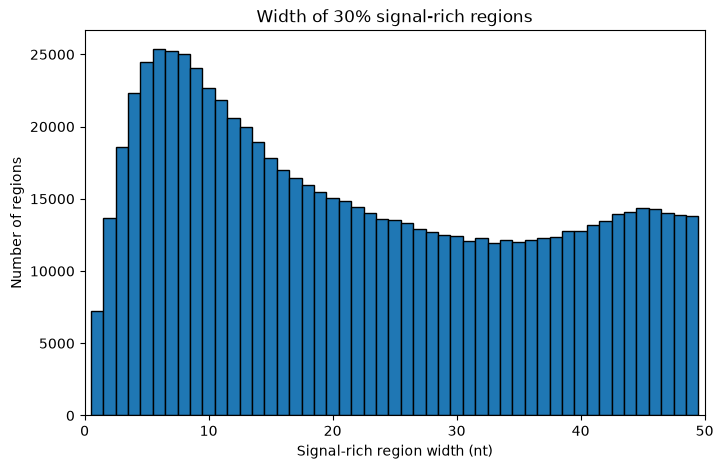

≤  1 nt: 0.4%
≤  2 nt: 1.2%
≤  3 nt: 2.4%
≤  5 nt: 5.2%
≤ 10 nt: 12.5%


In [8]:
signal_fraction = 0.30

window_max = detection_signal.max(axis=1, keepdims=True)
signal_mask = (window_max > 0) & (detection_signal >= signal_fraction * window_max)

region_lengths = []

for mask in signal_mask:
    padded = np.pad(mask.astype(int), 1)
    changes = np.diff(padded)
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]
    region_lengths.extend(ends - starts)

region_lengths = np.array(region_lengths)

plt.figure(figsize=(8, 5))
plt.hist(region_lengths, bins=np.arange(0.5, 50.5, 1), edgecolor="black")
plt.xlabel("Signal-rich region width (nt)")
plt.ylabel("Number of regions")
plt.title("Width of 30% signal-rich regions")
plt.xlim(0, 50)
plt.show()

for cutoff in [1, 2, 3, 5, 10]:
    print(f"≤ {cutoff:2d} nt: {np.mean(region_lengths <= cutoff):.1%}")

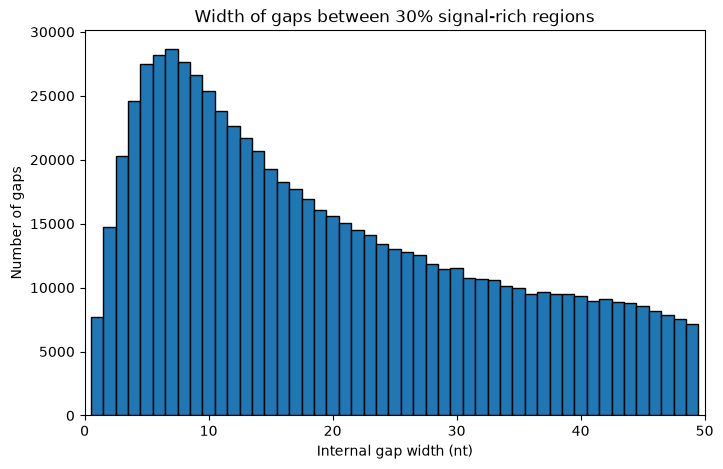

≤  1 nt: 0.8%
≤  2 nt: 2.3%
≤  3 nt: 4.5%
≤  5 nt: 9.9%
≤ 10 nt: 24.2%


In [9]:
gap_lengths = []

for mask in signal_mask:
    pos = np.flatnonzero(mask)
    if len(pos) < 2:
        continue

    internal = mask[pos[0]:pos[-1] + 1]
    padded = np.pad((~internal).astype(int), 1)
    changes = np.diff(padded)

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]
    gap_lengths.extend(ends - starts)

gap_lengths = np.array(gap_lengths)

plt.figure(figsize=(8, 5))
plt.hist(gap_lengths, bins=np.arange(0.5, 50.5, 1), edgecolor="black")
plt.xlabel("Internal gap width (nt)")
plt.ylabel("Number of gaps")
plt.title("Width of gaps between 30% signal-rich regions")
plt.xlim(0, 50)
plt.show()

for cutoff in [1, 2, 3, 5, 10]:
    print(f"≤ {cutoff:2d} nt: {np.mean(gap_lengths <= cutoff):.1%}")

In [10]:
idx = 512879
mask = signal_mask[idx]

pos = np.flatnonzero(mask)
internal = mask[pos[0]:pos[-1] + 1]

padded = np.pad((~internal).astype(int), 1)
changes = np.diff(padded)

starts = np.where(changes == 1)[0] + pos[0]
ends = np.where(changes == -1)[0] + pos[0]

for start, end in zip(starts, ends):
    print(f"Gap {start}-{end - 1}: {end - start} nt")

Gap 21-24: 4 nt
Gap 105-114: 10 nt
Gap 213-215: 3 nt


In [11]:
def clean_signal_regions(mask, max_gap=5, min_region=5):
    mask = mask.copy()

    # 1. Bridge internal gaps <= max_gap
    pos = np.flatnonzero(mask)
    if len(pos) > 1:
        internal = mask[pos[0]:pos[-1] + 1]
        padded = np.pad((~internal).astype(int), 1)
        changes = np.diff(padded)

        starts = np.where(changes == 1)[0] + pos[0]
        ends = np.where(changes == -1)[0] + pos[0]

        for start, end in zip(starts, ends):
            if end - start <= max_gap:
                mask[start:end] = True

    # 2. Remove signal-rich regions <= min_region
    padded = np.pad(mask.astype(int), 1)
    changes = np.diff(padded)

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    for start, end in zip(starts, ends):
        if end - start <= min_region:
            mask[start:end] = False

    return mask


clean_signal_mask = np.array([
    clean_signal_regions(mask, max_gap=5, min_region=5)
    for mask in signal_mask
])

# Check duplication feasibility

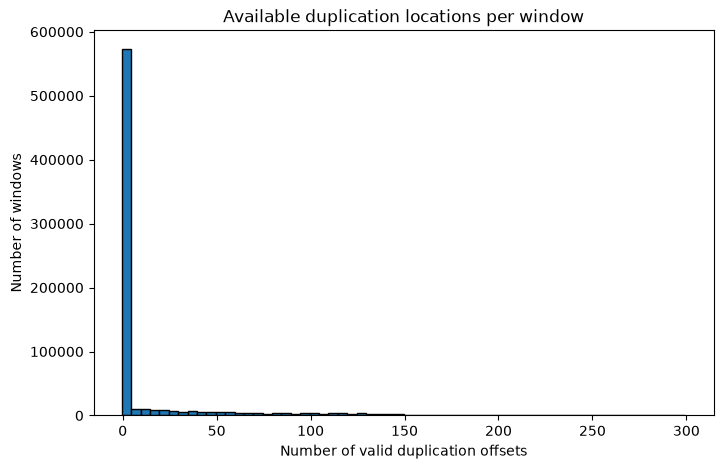

≥  1 valid offsets: 21.4%
≥  5 valid offsets: 20.1%
≥ 10 valid offsets: 18.6%
≥ 25 valid offsets: 14.9%
≥ 50 valid offsets: 10.5%


In [12]:
from scipy.signal import fftconvolve

def count_duplication_offsets(masks, batch_size=10000):
    n, width = masks.shape
    lags = np.arange(-(width - 1), width)
    valid_counts = np.zeros(n, dtype=np.int16)

    for start in range(0, n, batch_size):
        m = masks[start:start + batch_size].astype(np.float32)
        has_signal = m.any(axis=1)

        first = np.argmax(m, axis=1)
        last = width - 1 - np.argmax(m[:, ::-1], axis=1)

        # Number of signal-rich positions overlapping at every possible shift.
        overlap = np.rint(fftconvolve(m, m[:, ::-1], mode="full", axes=1)).astype(np.int16)

        in_bounds = (
            (lags[None, :] >= -first[:, None]) &
            (lags[None, :] <= width - 1 - last[:, None])
        )

        valid = has_signal[:, None] & in_bounds & (overlap == 0) & (lags[None, :] != 0)
        valid_counts[start:start + len(m)] = valid.sum(axis=1)

    return valid_counts


duplication_options = count_duplication_offsets(clean_signal_mask)

plt.figure(figsize=(8, 5))
plt.hist(duplication_options, bins=np.arange(-0.5, 300.5, 5), edgecolor="black")
plt.xlabel("Number of valid duplication offsets")
plt.ylabel("Number of windows")
plt.title("Available duplication locations per window")
plt.show()

for cutoff in [1, 5, 10, 25, 50]:
    print(f"≥ {cutoff:2d} valid offsets: {np.mean(duplication_options >= cutoff):.1%}")